# Gambaran Umum Dataset
Tahap ini bertujuan untuk memahami karakteristik awal dataset, meliputi:

- Pemeriksaan missing value
- Pemeriksaan data duplikat
- Jumlah entitas unik seperti trip, rute, dan segmen
- Statistik deskriptif dari seluruh kolom

Hasil analisis ini digunakan untuk menentukan apakah diperlukan proses pembersihan data sebelum tahap feature engineering dan pemodelan.

In [ ]:
# ============================================================
# FASE 1 — LOAD LIBRARY & DATASET
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Root project (folder utama repository)
BASE = Path("..")

# Folder project
DATA_DIR = BASE / "data"
OUTPUT_DIR = BASE / "output"
MODEL_DIR = BASE / "models"
ASSET_DIR = BASE / "assets"

# Pastikan folder output tersedia
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
ASSET_DIR.mkdir(exist_ok=True)

# Load dataset
DATA_PATH = DATA_DIR / "AI_Engineer_dataset.parquet"

df = pd.read_parquet(DATA_PATH)

# Konversi kolom waktu
df["arrival_time"] = pd.to_datetime(df["arrival_time"])
df["from_arrival_time_str"] = pd.to_datetime(df["from_arrival_time_str"])

print(f"Dataset berhasil dimuat: {df.shape[0]:,} baris × {df.shape[1]} kolom")

display(df.head())

print("\nInformasi Dataset")
df.info()

print("\nMissing Values")
display(df.isna().sum())

print(f"\nJumlah duplicate rows : {df.duplicated().sum()}")

print("\nJumlah data unik")
print(f"Trip      : {df['trip_id'].nunique():,}")
print(f"Route     : {df['route_code'].nunique():,}")
print(f"Segment   : {df['segment_id'].nunique():,}")

display(df.describe(include='all').T)

Mounted at /content/drive
(351103, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351103 entries, 0 to 351102
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   bus_body_no            351103 non-null  object 
 1   segment_id             351103 non-null  object 
 2   route_code             351103 non-null  object 
 3   trip_id                351103 non-null  object 
 4   stop_sequence          351103 non-null  int64  
 5   traveling_time_sec     351103 non-null  float64
 6   from_arrival_time_str  351103 non-null  object 
 7   arrival_time           351103 non-null  object 
 8   average_time_sec       351103 non-null  float64
 9   no_do                  351103 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 26.8+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
bus_body_no,351103,259,BUS-DUMMY-003490,5912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment_id,351103,44,SEG-DUMMY-008870,10736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
route_code,351103,1,ROUTE-DUMMY-0001,351103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trip_id,351103,13,TRIP-DUMMY-000012,106478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stop_sequence,351103.0,NaN,NaN,NaN,12.082121,7.537613,1.0,6.0,12.0,17.0,35.0
traveling_time_sec,351103.0,NaN,NaN,NaN,467.327755,7331.544113,0.222,60.365,89.067,165.4005,958259.716
from_arrival_time_str,351103,316647,2026-02-07 18:23:40,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_time,351103,318961,2026-02-07 19:15:50,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
average_time_sec,351103.0,NaN,NaN,NaN,461.916547,5433.855815,9.825727,62.667006,89.74202,170.475347,1095264.682989
no_do,351103,17857,DO-DUMMY-00089188,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Investigasi Struktur Perjalanan

Berdasarkan dokumentasi awal, terdapat kolom `no_do` yang diduga merepresentasikan satu perjalanan bus.

Untuk memverifikasi asumsi tersebut dilakukan beberapa pemeriksaan:

1. Hubungan antara `no_do` dan `trip_id`
2. Jumlah stop sequence dalam setiap `no_do`
3. Keberadaan stop sequence yang berulang dalam satu perjalanan
4. Jumlah `no_do` yang terkait dengan setiap `trip_id`

Tujuan analisis ini adalah memastikan apakah `no_do` dapat digunakan sebagai identitas unik perjalanan.

In [2]:
# 1. Apakah 1 no_do hanya terkait ke 1 trip_id?
print(df.groupby('no_do')['trip_id'].nunique().value_counts())

# 2. Distribusi jumlah baris per no_do (harusnya mirip jumlah halte per trip)
seq_per_do = df.groupby('no_do')['stop_sequence'].agg(['min','max','count'])
print(seq_per_do.describe())

# 3. Apakah ada stop_sequence duplikat dalam 1 no_do? (harusnya tidak ada / unique)
dupe_check = df.groupby(['no_do','stop_sequence']).size()
print((dupe_check > 1).sum(), 'baris dengan stop_sequence duplikat dalam 1 no_do')

# 4. Cross-check: dalam 1 trip_id, berapa banyak no_do berbeda?
print(df.groupby('trip_id')['no_do'].nunique())

trip_id
1    17856
2        1
Name: count, dtype: int64
                min           max         count
count  17857.000000  17857.000000  17857.000000
mean       1.242426     21.272162     19.661925
std        1.461949      5.924949      6.308747
min        1.000000      1.000000      1.000000
25%        1.000000     19.000000     17.000000
50%        1.000000     20.000000     19.000000
75%        1.000000     21.000000     21.000000
max       30.000000     35.000000     72.000000
2770 baris dengan stop_sequence duplikat dalam 1 no_do
trip_id
TRIP-DUMMY-000001     596
TRIP-DUMMY-000002    2398
TRIP-DUMMY-000003       2
TRIP-DUMMY-000004    1953
TRIP-DUMMY-000005     384
TRIP-DUMMY-000006       1
TRIP-DUMMY-000007       1
TRIP-DUMMY-000008     120
TRIP-DUMMY-000009      21
TRIP-DUMMY-000010      87
TRIP-DUMMY-000011     206
TRIP-DUMMY-000012    6300
TRIP-DUMMY-000013    5789
Name: no_do, dtype: int64


## Investigasi Data Duplikat Berdasarkan `no_do` dan `stop_sequence`

Pada tahap sebelumnya ditemukan adanya indikasi data duplikat. Untuk memahami penyebabnya, dilakukan analisis terhadap kombinasi `no_do` dan `stop_sequence`, karena secara logika satu perjalanan seharusnya hanya memiliki satu catatan untuk setiap urutan pemberhentian.

Analisis ini bertujuan untuk menjawab beberapa pertanyaan berikut:

- Berapa banyak data yang memiliki kombinasi `no_do` dan `stop_sequence` yang sama?
- Apakah duplikasi tersebut memiliki nilai `traveling_time_sec` yang identik atau berbeda?
- Apakah data duplikat berasal dari bus yang sama atau dari bus yang berbeda?
- Apakah terdapat pola tertentu yang menunjukkan bahwa duplikasi merupakan bagian dari proses operasional, seperti bus yang melakukan beberapa putaran perjalanan, atau justru mengindikasikan adanya kualitas data yang perlu diperhatikan?

Hasil investigasi ini akan digunakan untuk menentukan apakah data duplikat perlu dihapus, dipertahankan, atau ditangani dengan pendekatan khusus pada tahap feature engineering.

In [ ]:
dup_mask = df.duplicated(['no_do', 'stop_sequence'], keep=False)
dupes = df[dup_mask].sort_values(['no_do', 'stop_sequence', 'arrival_time'])
print(dupes.shape)
dupes.head(20)

dupes.groupby(['no_do','stop_sequence'])['traveling_time_sec'].nunique().value_counts()

# Apakah duplikat ini dari bus yang sama atau bus berbeda?
dupes.groupby(['no_do','stop_sequence'])['bus_body_no'].nunique().value_counts()

# Lihat contoh konkret — termasuk kasus ekstrem (8 nilai berbeda)
dupes.groupby(['no_do','stop_sequence']).filter(
    lambda g: g['traveling_time_sec'].nunique() == 8
)

# Contoh kasus biasa (2 nilai berbeda) untuk lihat selisihnya wajar atau ekstrem
sample_groups = dupes.groupby(['no_do','stop_sequence'])['traveling_time_sec'].nunique()
sample_keys = sample_groups[sample_groups == 2].index[:5]
for k in sample_keys:
    print(dupes[(dupes['no_do']==k[0]) & (dupes['stop_sequence']==k[1])])
    print('---')

(5662, 10)
             bus_body_no        segment_id        route_code  \
300749  BUS-DUMMY-000213  SEG-DUMMY-008734  ROUTE-DUMMY-0001   
300945  BUS-DUMMY-000213  SEG-DUMMY-008734  ROUTE-DUMMY-0001   

                  trip_id  stop_sequence  traveling_time_sec  \
300749  TRIP-DUMMY-000012              1             266.049   
300945  TRIP-DUMMY-000012              1            5451.557   

       from_arrival_time_str         arrival_time  average_time_sec  \
300749   2026-02-01 02:09:06  2026-02-01 02:13:32      29605.009693   
300945   2026-02-01 02:39:10  2026-02-01 04:10:02       3138.992874   

                    no_do  
300749  DO-DUMMY-00003876  
300945  DO-DUMMY-00003876  
---
             bus_body_no        segment_id        route_code  \
300759  BUS-DUMMY-000213  SEG-DUMMY-009388  ROUTE-DUMMY-0001   
300948  BUS-DUMMY-000213  SEG-DUMMY-009388  ROUTE-DUMMY-0001   

                  trip_id  stop_sequence  traveling_time_sec  \
300759  TRIP-DUMMY-000012              2    

In [4]:
df['arrival_time'] = pd.to_datetime(df['arrival_time'])
dup_mask = df.duplicated(['no_do','stop_sequence'], keep=False)
dupes = df[dup_mask].copy()

gap_minutes = dupes.groupby(['no_do','stop_sequence'])['arrival_time'].agg(
    lambda x: (x.max() - x.min()).total_seconds() / 60
)
print(gap_minutes.describe())
print('Gap besar (>30 menit, kemungkinan Pola B - loop berulang):', (gap_minutes > 30).sum())
print('Gap kecil (<=30 menit, kemungkinan Pola A - dwell/idle logging):', (gap_minutes <= 30).sum())

count    2770.000000
mean      119.067918
std        84.382017
min         0.050000
25%        91.437500
50%       111.141667
75%       130.733333
max      1780.283333
Name: arrival_time, dtype: float64
Gap besar (>30 menit, kemungkinan Pola B - loop berulang): 2583
Gap kecil (<=30 menit, kemungkinan Pola A - dwell/idle logging): 187


In [ ]:
df = df.sort_values(['no_do', 'arrival_time']).reset_index(drop=True)

# Rekonstruksi instance trip nyata (menangkap Pola B - loop berulang)
df['prev_seq'] = df.groupby('no_do')['stop_sequence'].shift(1)
df['seq_reset'] = (df['stop_sequence'] < (df['prev_seq'] - 2)).fillna(False)
df['trip_instance'] = df.groupby('no_do')['seq_reset'].cumsum()
df['real_trip_id'] = df['no_do'].astype(str) + '_' + df['trip_instance'].astype(str)

print('Jumlah no_do unik:', df['no_do'].nunique())
print('Jumlah real_trip_id unik (setelah split):', df['real_trip_id'].nunique())
print('Selisih (jumlah putaran yang awalnya tersembunyi):',
      df['real_trip_id'].nunique() - df['no_do'].nunique())

# Dwell dedup: untuk duplikat stop_sequence yang tersisa dalam 1 real_trip_id
df = df.sort_values(['real_trip_id', 'stop_sequence', 'arrival_time'])
df['is_dwell_duplicate'] = df.duplicated(['real_trip_id', 'stop_sequence'], keep='last')
print('Sisa dwell-duplicate setelah split real_trip_id:', df['is_dwell_duplicate'].sum())

df_clean = df[~df['is_dwell_duplicate']].copy()
print('Shape sebelum:', df.shape, '| Shape setelah dedup:', df_clean.shape)

Jumlah no_do unik: 17857
Jumlah real_trip_id unik (setelah split): 18344
Selisih (jumlah putaran yang awalnya tersembunyi): 487
Sisa dwell-duplicate setelah split real_trip_id: 184
Shape sebelum: (351103, 15) | Shape setelah dedup: (350919, 15)


Skewness asli: 58.34204536127939
Skewness log1p: 2.2253563788494484


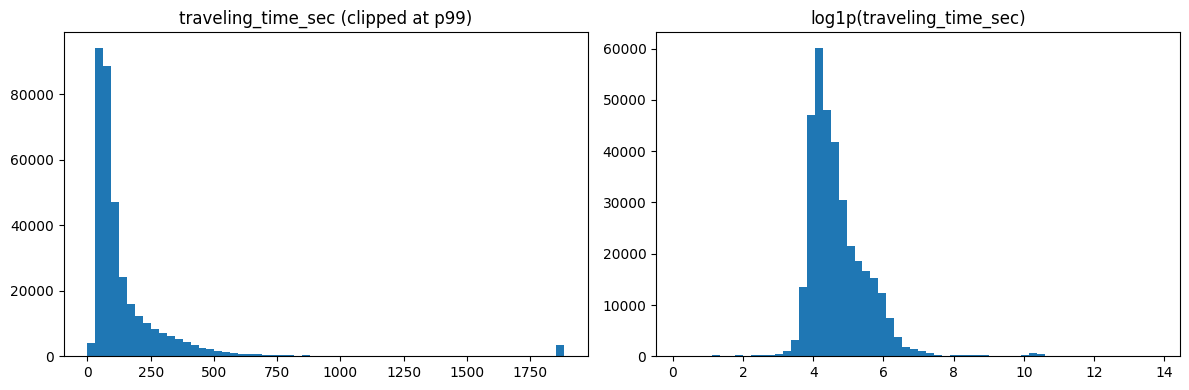

0.500        89.054000
0.900       330.723600
0.950       458.717300
0.990      1882.015280
0.999     44482.057964
1.000    958259.716000
Name: traveling_time_sec, dtype: float64


In [ ]:
print('Skewness asli:', df_clean['traveling_time_sec'].skew())
print('Skewness log1p:', np.log1p(df_clean['traveling_time_sec']).skew())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    df_clean['traveling_time_sec'].clip(
        upper=df_clean['traveling_time_sec'].quantile(0.99)
    ),
    bins=60
)
axes[0].set_title('traveling_time_sec (clipped at p99)')

axes[1].hist(
    np.log1p(df_clean['traveling_time_sec']),
    bins=60
)
axes[1].set_title('log1p(traveling_time_sec)')

plt.tight_layout()

plt.savefig(
    ASSET_DIR / "skewness_comparison.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

print(df_clean['traveling_time_sec'].quantile([0.5, 0.9, 0.95, 0.99, 0.999, 1.0]))

count    350919.000000
mean          0.986798
std           0.208895
min           0.000111
25%           0.911967
50%           0.999069
75%           1.084063
max           1.999611
Name: deviation_ratio, dtype: float64
0.500    0.999069
0.900    1.183141
0.950    1.260820
0.990    1.536751
0.999    1.950226
1.000    1.999611
Name: deviation_ratio, dtype: float64


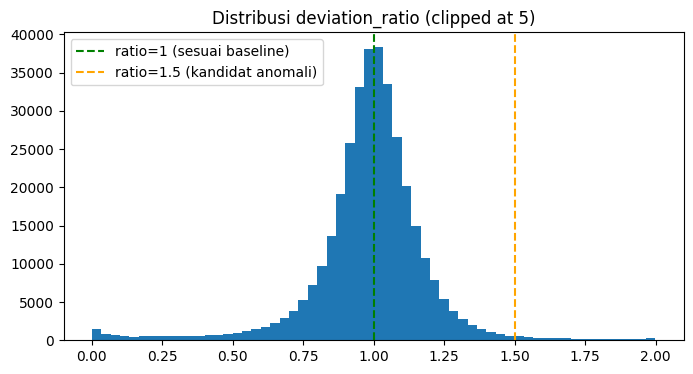

Proporsi baris dengan deviation_ratio > 1.5: 1.15%
Proporsi baris dengan deviation_ratio > 2.0: 0.00%
Proporsi baris dengan deviation_ratio > 3.0: 0.00%


In [ ]:
df_clean['deviation_ratio'] = df_clean['traveling_time_sec'] / df_clean['average_time_sec']

print(df_clean['deviation_ratio'].describe())
print(df_clean['deviation_ratio'].quantile([0.5, 0.9, 0.95, 0.99, 0.999, 1.0]))

plt.figure(figsize=(8,4))

plt.hist(
    df_clean['deviation_ratio'].clip(upper=5),
    bins=60
)

plt.axvline(
    1.0,
    color='green',
    linestyle='--',
    label='ratio = 1'
)

plt.axvline(
    1.5,
    color='orange',
    linestyle='--',
    label='anomaly threshold'
)

plt.title("Distribution of Deviation Ratio")
plt.xlabel("Deviation Ratio")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()

plt.savefig(
    ASSET_DIR / "deviation_ratio_dist.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

for t in [1.5, 2.0, 3.0]:
    pct = (df_clean['deviation_ratio'] > t).mean() * 100
    print(f'Proporsi baris dengan deviation_ratio > {t}: {pct:.2f}%')

count    1029.000000
mean      341.029155
std       209.252666
min         1.000000
25%       101.000000
50%       385.000000
75%       511.000000
max       767.000000
dtype: float64
Proporsi kombinasi segment-hour dengan <5 baris: 0.49%
Proporsi kombinasi segment-hour dengan <10 baris: 0.87%
Proporsi kombinasi segment-hour dengan <20 baris: 1.55%
Proporsi kombinasi segment-hour dengan <30 baris: 3.50%


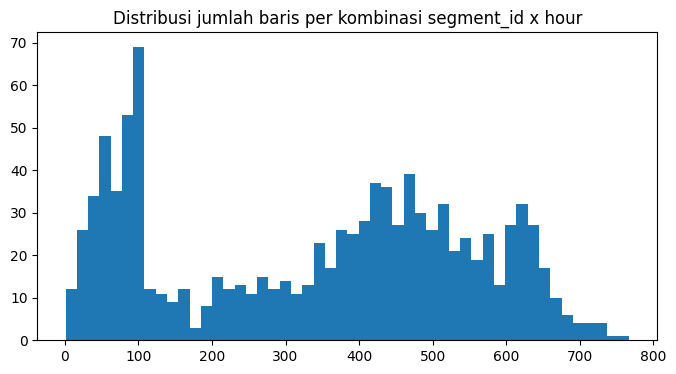


Level lebih granular (segment x hour x dow):
count    7124.000000
mean       49.258703
std        30.752695
min         1.000000
25%        16.000000
50%        53.000000
75%        74.000000
max       132.000000
dtype: float64


In [ ]:
df_clean['hour'] = df_clean['arrival_time'].dt.hour

seg_hour_counts = df_clean.groupby(['segment_id', 'hour']).size()

print(seg_hour_counts.describe())

for t in [5, 10, 20, 30]:
    pct = (seg_hour_counts < t).mean() * 100
    print(f'Proporsi kombinasi segment-hour dengan <{t} baris: {pct:.2f}%')

plt.figure(figsize=(8,4))

plt.hist(seg_hour_counts, bins=50)

plt.title('Distribusi jumlah baris per kombinasi segment_id × hour')
plt.xlabel('Jumlah observasi')
plt.ylabel('Frekuensi')

plt.tight_layout()

plt.savefig(
    ASSET_DIR / "sparsity_segment_hour.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

# sparsity di level lebih granular
df_clean['day_of_week'] = df_clean['arrival_time'].dt.dayofweek

seg_hour_dow_counts = df_clean.groupby(
    ['segment_id', 'hour', 'day_of_week']
).size()

print("\nLevel lebih granular (segment × hour × day_of_week)")
print(seg_hour_dow_counts.describe())

In [9]:
extreme = df_clean.sort_values('traveling_time_sec', ascending=False).head(15)
print(extreme[['real_trip_id','stop_sequence','traveling_time_sec','average_time_sec','deviation_ratio']])

print('\nKorelasi log(traveling_time_sec) vs log(average_time_sec):')
print(np.corrcoef(np.log1p(df_clean['traveling_time_sec']), np.log1p(df_clean['average_time_sec']))[0,1])

               real_trip_id  stop_sequence  traveling_time_sec  \
351101  DO-DUMMY-00336973_0              1          958259.716   
351066  DO-DUMMY-00336675_0              1          943435.941   
351102  DO-DUMMY-00336976_0              1          786863.259   
351097  DO-DUMMY-00336959_0              1          775976.398   
351098  DO-DUMMY-00336963_0              1          774360.903   
129915  DO-DUMMY-00129096_0              1          725990.784   
351099  DO-DUMMY-00336966_0              1          698124.197   
351096  DO-DUMMY-00336945_0              1          691822.554   
351100  DO-DUMMY-00336970_0              1          688783.670   
237152  DO-DUMMY-00226535_0              1          547569.856   
351075  DO-DUMMY-00336809_0              1          473817.640   
211370  DO-DUMMY-00201040_0              1          471379.359   
287462  DO-DUMMY-00273134_0              1          469072.006   
288364  DO-DUMMY-00274290_0              1          463181.300   
283381  DO

In [ ]:
# ===== FASE 3 =====

# 3.1 — is_gap_suspected (final, pakai real_trip_id yang sudah benar)
df_clean = df_clean.sort_values(['real_trip_id', 'stop_sequence'])
df_clean['seq_diff_final'] = df_clean.groupby('real_trip_id')['stop_sequence'].diff()
df_clean['is_gap_suspected'] = df_clean['seq_diff_final'].gt(1).fillna(False)

# tambahan: flag kalau trip tidak mulai dari stop_sequence terendah seharusnya
first_seq = df_clean.groupby('real_trip_id')['stop_sequence'].transform('min')
df_clean['incomplete_start_suspected'] = (df_clean['stop_sequence'] == first_seq) & (first_seq > 1)

print('Proporsi baris is_gap_suspected:', df_clean['is_gap_suspected'].mean())
print('Proporsi trip dengan incomplete_start:',
      df_clean.groupby('real_trip_id')['incomplete_start_suspected'].max().mean())

# 3.2 — deviation_ratio + dua tingkat anomaly flag
df_clean['deviation_ratio'] = df_clean['traveling_time_sec'] / df_clean['average_time_sec']
df_clean['log_deviation_ratio'] = np.log1p(df_clean['deviation_ratio'])

ANOMALY_RATIO_THRESHOLD = 1.5
DATA_ERROR_TIME_THRESHOLD = df_clean['traveling_time_sec'].quantile(0.999)

df_clean['anomaly_suspected'] = df_clean['deviation_ratio'] > ANOMALY_RATIO_THRESHOLD
df_clean['data_error_suspected'] = df_clean['traveling_time_sec'] > DATA_ERROR_TIME_THRESHOLD

print('Proporsi anomaly_suspected (rasio):', df_clean['anomaly_suspected'].mean())
print('Proporsi data_error_suspected (absolut, threshold=%.0f detik):' % DATA_ERROR_TIME_THRESHOLD,
      df_clean['data_error_suspected'].mean())

missed = df_clean[df_clean['data_error_suspected'] & ~df_clean['anomaly_suspected']]
print('Kasus data_error_suspected tapi LOLOS dari anomaly_suspected (rasio):', len(missed))

Proporsi baris is_gap_suspected: 0.03557231155907774
Proporsi trip dengan incomplete_start: 0.06323593545573485
Proporsi anomaly_suspected (rasio): 0.01154682419589706
Proporsi data_error_suspected (absolut, threshold=44482 detik): 0.0010002308224974993
Kasus data_error_suspected tapi LOLOS dari anomaly_suspected (rasio): 101


In [11]:
print(df_clean[df_clean['data_error_suspected']]['stop_sequence'].value_counts().head(10))
print('\nProporsi stop_sequence==1 di antara seluruh data:', (df_clean['stop_sequence']==1).mean())

stop_sequence
1    351
Name: count, dtype: int64

Proporsi stop_sequence==1 di antara seluruh data: 0.048968565395433136
